# 🔧 Notebook 3: Feature Engineering

## Goal
Feature engineering is the **art of creating new columns** from existing data that make patterns easier to find. A well-engineered feature can reveal insights that raw data hides.

We'll create these features:

| Feature | Purpose |
|---|---|
| `Game_Age` | How old is the game (years since release)? |
| `Release_Decade` | Group games into decades (1980s, 1990s, etc.) |
| `Top_Region` | Which region generated the most sales? |
| `NA_Share`, `EU_Share`, `JP_Share`, `Other_Share` | Regional sales as % of global |
| `Platform_Era` | Classify platforms by technological generation |
| `Sales_Category` | Classify games by sales volume (Mega Hit, Hit, etc.) |

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

import warnings
warnings.filterwarnings('ignore')

# Load the cleaned dataset from Notebook 02
df = pd.read_csv('../Data/processed/cleaned_vgsales.csv')
print(f'Loaded cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Loaded cleaned dataset: 16,327 rows × 11 columns


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 2. Game Age

**Intuition**: How old is each game? Older games have had more time to accumulate sales. This feature helps us compare games fairly or segment by "vintage".

Formula: `Game_Age = 2026 - Year`

Game Age range: 6 – 46 years
Average game age: 19.6 years


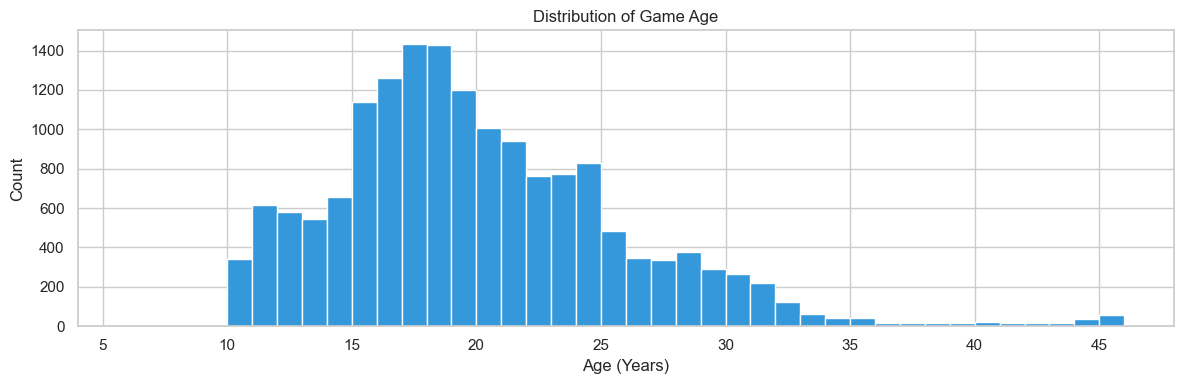

In [2]:
# Create Game_Age
CURRENT_YEAR = 2026
df['Game_Age'] = CURRENT_YEAR - df['Year']

print(f'Game Age range: {df["Game_Age"].min()} – {df["Game_Age"].max()} years')
print(f'Average game age: {df["Game_Age"].mean():.1f} years')

# Quick visualization
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df['Game_Age'], bins=40, color='#3498db', edgecolor='white')
ax.set_title('Distribution of Game Age')
ax.set_xlabel('Age (Years)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Release Decade

**Intuition**: Grouping by individual years gives noisy trends. Decades offer cleaner, broader comparisons — "How did the 2000s compare to the 1990s?"

Formula: `Release_Decade = (Year // 10) * 10` → e.g., 2007 → 2000

Games per Decade:
Release_Decade_Label
1980s     205
1990s    1769
2000s    9208
2010s    5144
2020s       1
Name: count, dtype: int64


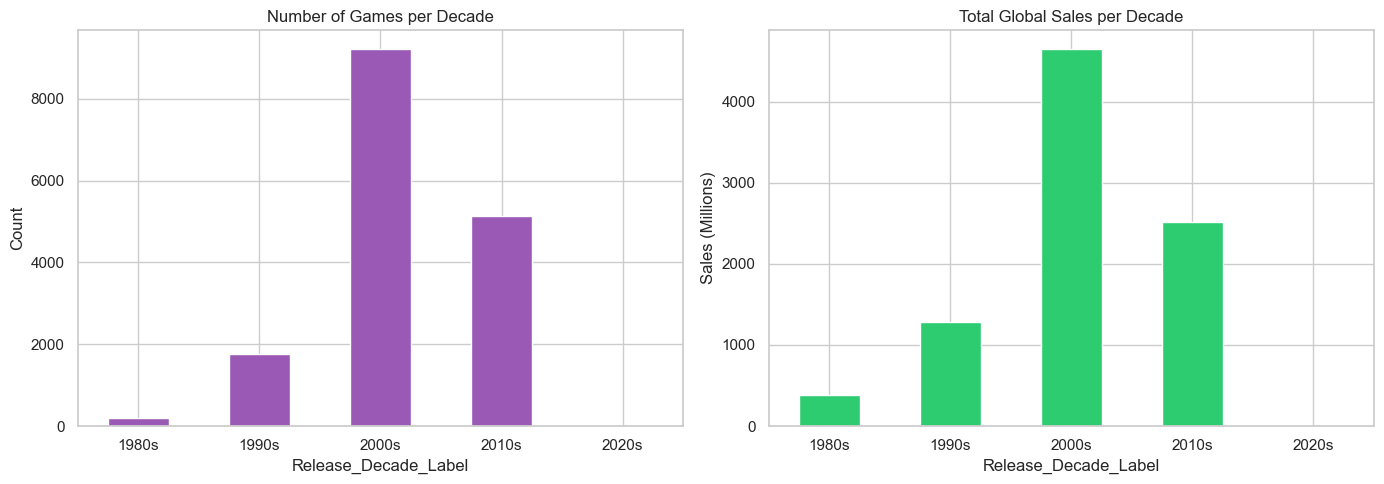

💡 The 2000s had the most games AND the highest total sales — the golden age of console gaming.


In [3]:
# Create Release_Decade
df['Release_Decade'] = (df['Year'] // 10) * 10
df['Release_Decade_Label'] = df['Release_Decade'].astype(str) + 's'

print('Games per Decade:')
print(df['Release_Decade_Label'].value_counts().sort_index())

# Visualization
decade_sales = df.groupby('Release_Decade_Label')['Global_Sales'].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Release_Decade_Label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('Number of Games per Decade')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

decade_sales.plot(kind='bar', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Total Global Sales per Decade')
axes[1].set_ylabel('Sales (Millions)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('💡 The 2000s had the most games AND the highest total sales — the golden age of console gaming.')

## 4. Top Region

**Intuition**: For each game, which region was the **biggest market**? This tells us about regional appeal — a game that sells most in Japan is likely a JRPG, while one that sells most in NA might be a shooter.

We compare NA, EU, JP, and Other sales and pick the largest.

Top Region Distribution:
Top_Region
North America    9925
Japan            3986
Europe           2340
Other              76
Name: count, dtype: int64


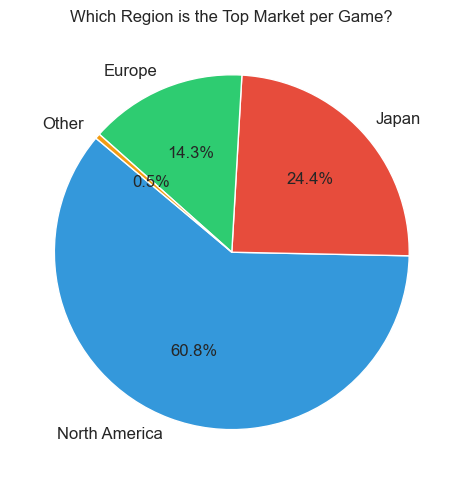

💡 North America is the top market for the majority of games in this dataset.


In [4]:
# Create Top_Region
region_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
region_labels = {'NA_Sales': 'North America', 'EU_Sales': 'Europe',
                 'JP_Sales': 'Japan', 'Other_Sales': 'Other'}

df['Top_Region'] = df[region_cols].idxmax(axis=1).map(region_labels)

print('Top Region Distribution:')
print(df['Top_Region'].value_counts())

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'North America': '#3498db', 'Europe': '#2ecc71', 'Japan': '#e74c3c', 'Other': '#f39c12'}
top_reg_counts = df['Top_Region'].value_counts()
ax.pie(top_reg_counts, labels=top_reg_counts.index, autopct='%1.1f%%',
       colors=[colors[r] for r in top_reg_counts.index], startangle=140,
       textprops={'fontsize': 12})
ax.set_title('Which Region is the Top Market per Game?')
plt.tight_layout()
plt.show()

print('💡 North America is the top market for the majority of games in this dataset.')

## 5. Regional Sales Share

**Intuition**: Instead of absolute sales, **what percentage** of a game's total sales came from each region? This normalizes for game popularity and reveals regional bias.

For example, a game with 80% Japan share is a very "Japanese" title.

In [5]:
# Calculate regional shares (avoid division by zero)
for col, name in [('NA_Sales', 'NA_Share'), ('EU_Sales', 'EU_Share'),
                   ('JP_Sales', 'JP_Share'), ('Other_Sales', 'Other_Share')]:
    df[name] = np.where(df['Global_Sales'] > 0,
                        (df[col] / df['Global_Sales'] * 100).round(2),
                        0)

print('Regional Share Statistics (%):\n')
print(df[['NA_Share', 'EU_Share', 'JP_Share', 'Other_Share']].describe().round(2))

Regional Share Statistics (%):

       NA_Share  EU_Share  JP_Share  Other_Share
count  16327.00  16327.00  16327.00     16327.00
mean      45.40     22.94     24.38         6.47
std       34.04     24.92     40.23         7.96
min        0.00      0.00      0.00         0.00
25%        0.00      0.00      0.00         0.00
50%       50.00     20.00      0.00         5.56
75%       75.00     37.50     36.30        10.25
max      100.00    100.00    100.00       100.00


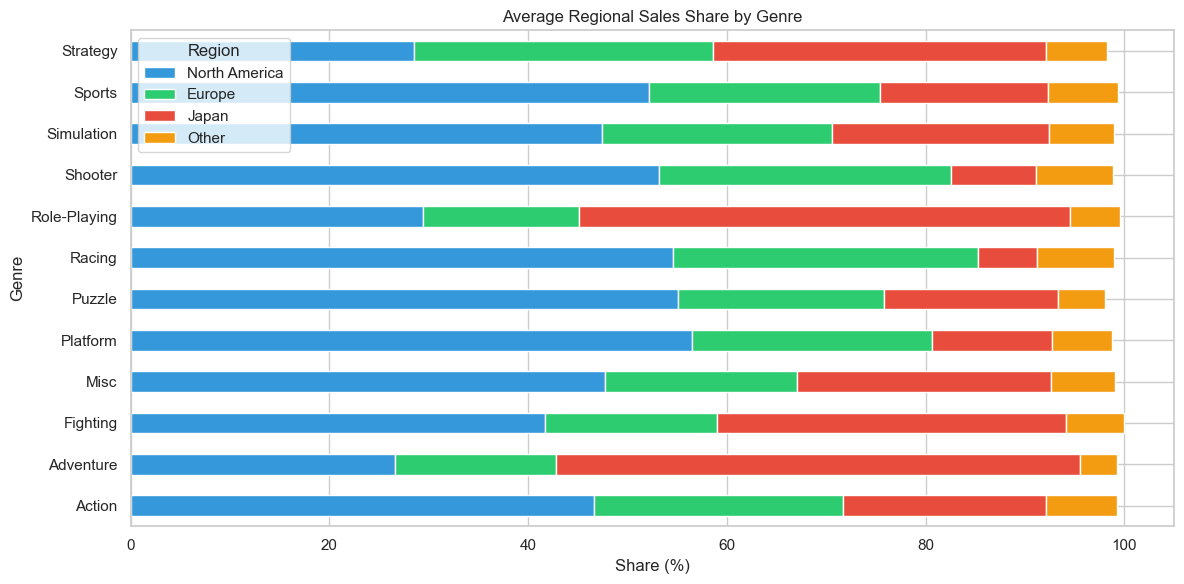

💡 Role-Playing games have the highest Japan share — reflecting the JRPG tradition.
   Shooters are dominated by North America.


In [6]:
# Average regional share by genre — reveals which genres are popular where
share_by_genre = df.groupby('Genre')[['NA_Share', 'EU_Share', 'JP_Share', 'Other_Share']].mean().round(1)

fig, ax = plt.subplots(figsize=(12, 6))
share_by_genre.plot(kind='barh', stacked=True, ax=ax,
                    color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
ax.set_title('Average Regional Sales Share by Genre')
ax.set_xlabel('Share (%)')
ax.legend(title='Region', labels=['North America', 'Europe', 'Japan', 'Other'])
plt.tight_layout()
plt.show()

print('💡 Role-Playing games have the highest Japan share — reflecting the JRPG tradition.')
print('   Shooters are dominated by North America.')

## 6. Platform Era

**Intuition**: Gaming platforms span several technology generations. Grouping them reveals how the market shifted from early consoles (Atari) to modern ones (PS4, XOne).

| Era | Platforms | Approximate Period |
|---|---|---|
| Retro | 2600, NES, GB, SNES, GEN | Pre-1995 |
| Transition | N64, PS, GBC, DC, GBA | 1995–2001 |
| Golden | PS2, XB, GC, DS, PSP | 2000–2006 |
| Modern | X360, PS3, Wii, 3DS, PSV | 2005–2013 |
| Current | PS4, XOne, WiiU, PC | 2013+ |

In [7]:
# Define platform eras
platform_era_map = {
    # Retro era
    '2600': 'Retro', 'NES': 'Retro', 'GB': 'Retro', 'SNES': 'Retro', 'GEN': 'Retro',
    'SCD': 'Retro', 'TG16': 'Retro', 'GG': 'Retro', '3DO': 'Retro', 'PCFX': 'Retro',
    'NG': 'Retro', 'WS': 'Retro',
    # Transition era
    'N64': 'Transition', 'PS': 'Transition', 'GBC': 'Transition', 'DC': 'Transition',
    'SAT': 'Transition',
    # Golden era
    'PS2': 'Golden', 'XB': 'Golden', 'GC': 'Golden', 'GBA': 'Golden',
    'DS': 'Golden', 'PSP': 'Golden',
    # Modern era
    'X360': 'Modern', 'PS3': 'Modern', 'Wii': 'Modern', '3DS': 'Modern',
    'PSV': 'Modern',
    # Current era
    'PS4': 'Current', 'XOne': 'Current', 'WiiU': 'Current', 'PC': 'Current'
}

df['Platform_Era'] = df['Platform'].map(platform_era_map).fillna('Other')

print('Games per Platform Era:')
era_order = ['Retro', 'Transition', 'Golden', 'Modern', 'Current', 'Other']
print(df['Platform_Era'].value_counts().reindex(era_order))

Games per Platform Era:
Platform_Era
Retro          608.0
Transition    1730.0
Golden        7613.0
Modern        4741.0
Current       1635.0
Other            NaN
Name: count, dtype: float64


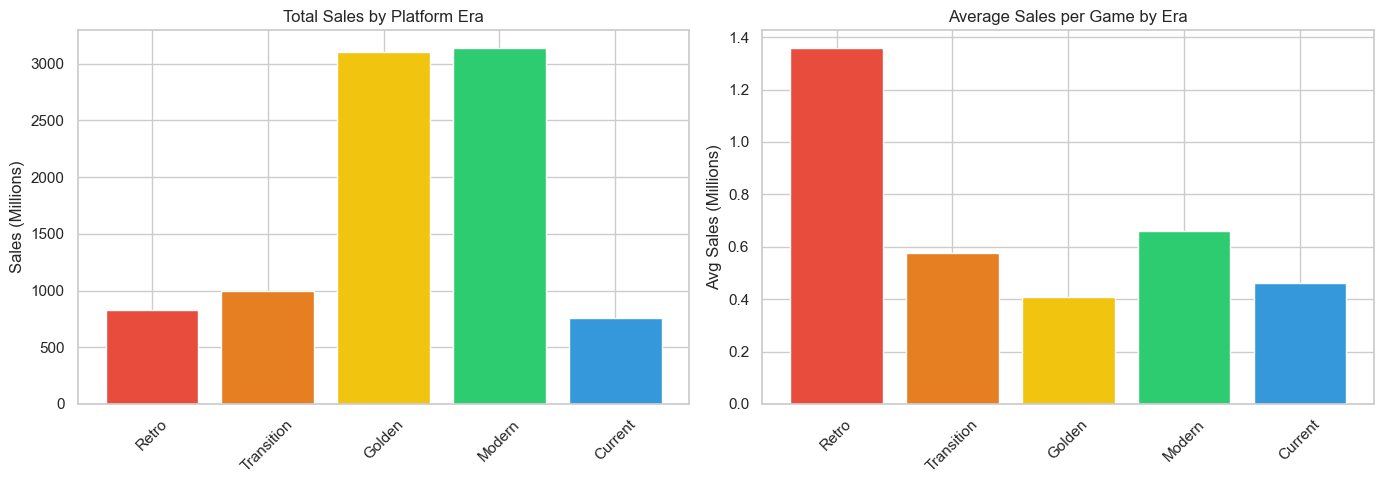

💡 The Golden and Modern eras generated the most total sales.
   But Retro/Transition era games had higher average sales — fewer games, bigger hits.


In [8]:
# Sales by platform era
era_sales = df.groupby('Platform_Era')['Global_Sales'].agg(['sum', 'mean', 'count'])
era_sales.columns = ['Total_Sales', 'Avg_Sales', 'Game_Count']
era_sales = era_sales.reindex(era_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

era_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#95a5a6']
axes[0].bar(era_sales.index, era_sales['Total_Sales'], color=era_colors)
axes[0].set_title('Total Sales by Platform Era')
axes[0].set_ylabel('Sales (Millions)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(era_sales.index, era_sales['Avg_Sales'], color=era_colors)
axes[1].set_title('Average Sales per Game by Era')
axes[1].set_ylabel('Avg Sales (Millions)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('💡 The Golden and Modern eras generated the most total sales.')
print('   But Retro/Transition era games had higher average sales — fewer games, bigger hits.')

## 7. Sales Category

**Intuition**: Categorize games by commercial success to easily filter "mega hits" versus "niche titles".

| Category | Global Sales Range |
|---|---|
| Mega Hit | > 10M |
| Hit | 1M – 10M |
| Moderate | 0.5M – 1M |
| Low | < 0.5M |

Sales Category Distribution:
Sales_Category
Mega Hit       62
Hit          1970
Moderate     1863
Low         12432
Name: count, dtype: int64


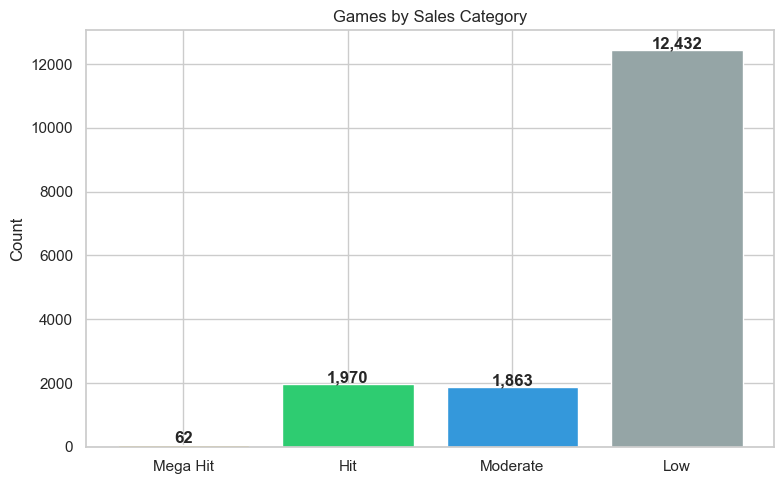

💡 Most games are "Low" sellers. Only a tiny fraction become Mega Hits.
   Mega Hits: 62 games (0.38%)


In [9]:
# Create Sales_Category
def categorize_sales(sales):
    if sales > 10:
        return 'Mega Hit'
    elif sales > 1:
        return 'Hit'
    elif sales > 0.5:
        return 'Moderate'
    else:
        return 'Low'

df['Sales_Category'] = df['Global_Sales'].apply(categorize_sales)

cat_order = ['Mega Hit', 'Hit', 'Moderate', 'Low']
print('Sales Category Distribution:')
print(df['Sales_Category'].value_counts().reindex(cat_order))

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
cat_counts = df['Sales_Category'].value_counts().reindex(cat_order)
cat_colors = ['#f1c40f', '#2ecc71', '#3498db', '#95a5a6']
ax.bar(cat_counts.index, cat_counts.values, color=cat_colors, edgecolor='white')
ax.set_title('Games by Sales Category')
ax.set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Most games are "Low" sellers. Only a tiny fraction become Mega Hits.')
print(f'   Mega Hits: {cat_counts["Mega Hit"]} games ({cat_counts["Mega Hit"]/len(df)*100:.2f}%)')

## 8. Review All New Features

In [10]:
new_cols = ['Game_Age', 'Release_Decade', 'Release_Decade_Label', 'Top_Region',
            'NA_Share', 'EU_Share', 'JP_Share', 'Other_Share',
            'Platform_Era', 'Sales_Category']

print(f'New features created: {len(new_cols)}')
print(f'Dataset now has {df.shape[1]} columns (was 11)\n')

df[['Name', 'Platform', 'Year', 'Genre', 'Global_Sales'] + new_cols].head(10)

New features created: 10
Dataset now has 21 columns (was 11)



,Name,Platform,Year,Genre,Global_Sales,Game_Age,Release_Decade,Release_Decade_Label,Top_Region,NA_Share,EU_Share,JP_Share,Other_Share,Platform_Era,Sales_Category
0,Wii Sports,Wii,2006,Sports,82.74,20,2000,2000s,North America,50.15,35.07,4.56,10.22,Modern,Mega Hit
1,Super Mario Bros.,NES,1985,Platform,40.24,41,1980,1980s,North America,72.27,8.90,16.92,1.91,Retro,Mega Hit
2,Mario Kart Wii,Wii,2008,Racing,35.82,18,2000,2000s,North America,44.25,35.96,10.58,9.24,Modern,Mega Hit
3,Wii Sports Resort,Wii,2009,Sports,33.00,17,2000,2000s,North America,47.73,33.36,9.94,8.97,Modern,Mega Hit
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,31.37,30,1990,1990s,North America,35.93,28.34,32.58,3.19,Retro,Mega Hit
5,Tetris,GB,1989,Puzzle,30.26,37,1980,1980s,North America,76.67,7.47,13.95,1.92,Retro,Mega Hit
6,New Super Mario Bros.,DS,2006,Platform,30.01,20,2000,2000s,North America,37.92,30.76,21.66,9.66,Golden,Mega Hit
7,Wii Play,Wii,2006,Misc,29.02,20,2000,2000s,North America,48.35,31.70,10.10,9.82,Modern,Mega Hit
8,New Super Mario Bros. Wii,Wii,2009,Platform,28.62,17,2000,2000s,North America,50.98,24.67,16.42,7.90,Modern,Mega Hit
9,Duck Hunt,NES,1984,Shooter,28.31,42,1980,1980s,North America,95.13,2.23,0.99,1.66,Retro,Mega Hit


## 9. Save Enhanced Dataset

In [11]:
# Overwrite the cleaned file with the enhanced version
df.to_csv('../Data/processed/cleaned_vgsales.csv', index=False)
print('✅ Enhanced dataset saved to: Data/processed/cleaned_vgsales.csv')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Enhanced dataset saved to: Data/processed/cleaned_vgsales.csv
   Shape: 16,327 rows × 21 columns


## Summary

| Feature | Type | Purpose |
|---|---|---|
| `Game_Age` | Numeric | Years since release |
| `Release_Decade` | Categorical | Decade grouping (1980, 1990, …) |
| `Top_Region` | Categorical | Region with highest sales |
| `NA/EU/JP/Other_Share` | Numeric | Regional % of total sales |
| `Platform_Era` | Categorical | Technology generation |
| `Sales_Category` | Categorical | Low / Moderate / Hit / Mega Hit |

### Next Steps
In **Notebook 04**, we'll use these features for deep **Exploratory Data Analysis**.